In [14]:
import os
import sys
from pathlib import Path

workspace_root = Path.cwd().parent if Path.cwd().name == "tests" else Path.cwd()
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

import config.config as config
import pandas as pd
from sqlalchemy import URL, create_engine, text
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt 

load_dotenv(dotenv_path=workspace_root / ".env")

database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST", "localhost"),
    port=int(os.getenv("DB_PORT", "5432")),
    database=os.getenv("DB_NAME", "megabase0"),
)

engine = create_engine(database_url)
target_schema = config.get_schema(test=False)

In [ ]:
target_schema = "observatoire"

# 1. Question sur l'état courant

q_etab_actifs= text(f"""
    SELECT COUNT(*) AS nb_actifs
    FROM {target_schema}.fait_etablissement_version
    WHERE is_current = TRUE AND etat = 'A';
""")

with engine.connect() as conn:
    df_etab_actifs = pd.read_sql(q_etab_actifs, conn)
display(df_etab_actifs)

,nb_actifs
0,421842


,code_ape,nomenclature,nb_etablissements
0,68.20B,NAFRev2,61903
1,68.20A,NAFRev2,32449
2,94.99Z,NAFRev2,16448
3,70.22Z,NAFRev2,14340
4,70.10Z,NAFRev2,10872
5,53.20Z,NAFRev2,8478
6,81.10Z,NAFRev2,6624
7,81.21Z,NAFRev2,6378
8,47.99A,NAFRev2,6034
9,64.20Z,NAFRev2,5406


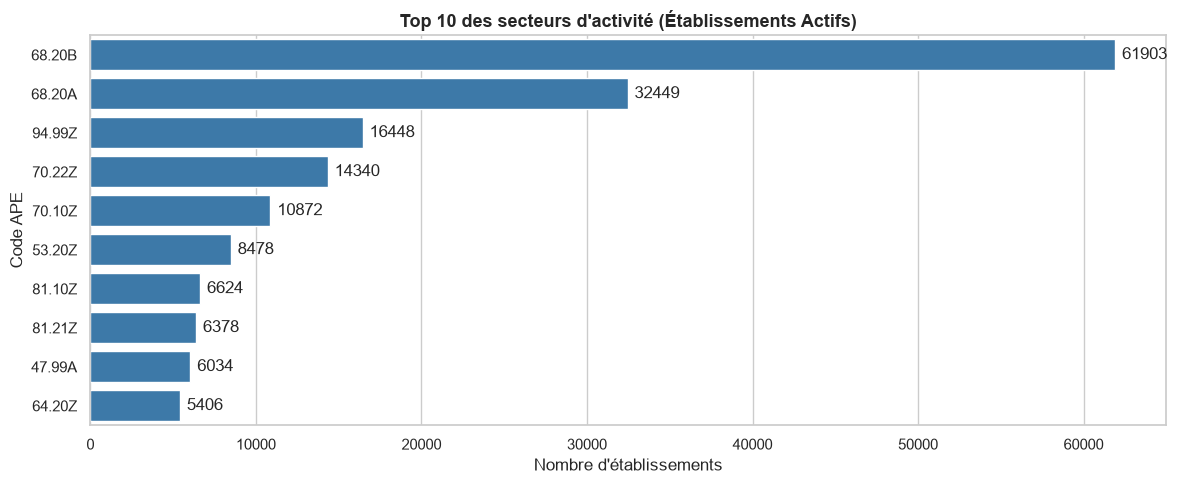

In [ ]:
q_top_secteurs = text(f"""
    SELECT a.code_ape, a.nomenclature, COUNT(f.siret) AS nb_etablissements
    FROM {target_schema}.fait_etablissement_version f
    JOIN {target_schema}.dim_activite a ON f.code_ape = a.code_ape
    WHERE f.is_current = TRUE AND f.etat = 'A'
    GROUP BY a.code_ape, a.nomenclature
    ORDER BY nb_etablissements DESC
    LIMIT 10;
""")

with engine.connect() as conn:
    df_top_secteurs = pd.read_sql(q_top_secteurs, conn)

display(df_top_secteurs)


# Les secteurs sont principalement de l'immobilier, de l'associatif


# plt.figure(figsize=(12, 5))
# sns.set_theme(style="whitegrid")

# ax = sns.barplot(
#     data=df_top_secteurs,
#     x="nb_etablissements",
#     y="code_ape",
#     color="#2b7bba"
# )

# plt.title("Top 10 des secteurs d'activité (Établissements Actifs)", fontsize=13, fontweight="bold")
# plt.xlabel("Nombre d'établissements")
# plt.ylabel("Code APE")

# for container in ax.containers:
#     ax.bar_label(container, padding=5, fmt="%d")

# plt.tight_layout()
# plt.show()

In [23]:

q_top_communes = text(f"""
    SELECT c.libelle_commune, COUNT(f.siret) AS nb_etablissements
    FROM {target_schema}.fait_etablissement_version f
    JOIN {target_schema}.dim_commune c ON f.code_commune = c.code_commune
    WHERE f.is_current = TRUE AND f.etat = 'A'
    GROUP BY c.libelle_commune
    ORDER BY nb_etablissements DESC
    LIMIT 10;
""")

with engine.connect() as conn: 
    df_top_communes = pd.read_sql(q_top_communes, conn)
display(df_top_communes)

,libelle_commune,nb_etablissements
0,LYON,58144
1,VILLEURBANNE,31316
2,LYON 6EME,23153
3,LYON 7EME,22149
4,LYON 8EME,14134
5,LYON 9EME,13241
6,LYON 1ER,12291
7,VENISSIEUX,9688
8,LYON 5EME,9264
9,VILLEFRANCHE-SUR-SAONE,8978


In [ ]:
# Bonus


In [ ]:
# 2. Une date passée

q_evo_secteurs = text(f"""
    WITH sect_2020 AS (
        SELECT code_ape, COUNT(*) AS nb_2020
        FROM {target_schema}.fait_etablissement_version
        WHERE valid_from <= '2020-01-01' 
          AND (valid_to > '2020-01-01' OR valid_to IS NULL) 
          AND etat = 'A'
        GROUP BY code_ape
    ),
    sect_current AS (
        SELECT code_ape, COUNT(*) AS nb_current
        FROM {target_schema}.fait_etablissement_version
        WHERE is_current = TRUE AND etat = 'A'
        GROUP BY code_ape
    )
    SELECT 
        c.code_ape,
        a.nomenclature, 
        COALESCE(p.nb_2020, 0) AS nb_2020,
        c.nb_current, 
        (c.nb_current - COALESCE(p.nb_2020, 0)) AS evolution
    FROM sect_current c
    LEFT JOIN sect_2020 p ON c.code_ape = p.code_ape
    JOIN {target_schema}.dim_activite a ON c.code_ape = a.code_ape
    ORDER BY evolution DESC;
""")

with engine.connect() as conn:
    df_evo_secteurs = pd.read_sql(q_evo_secteurs, conn)

display(df_evo_secteurs.head(10))
display(df_evo_secteurs.tail(10))

,code_ape,nomenclature,nb_2020,nb_current,evolution
0,68.20A,NAFRev2,19601,32449,12848
1,68.20B,NAFRev2,50371,61903,11532
2,70.10Z,NAFRev2,5438,10872,5434
3,70.22Z,NAFRev2,9735,14340,4605
4,53.20Z,NAFRev2,5136,8478,3342
5,66.30Z,NAFRev2,1311,4616,3305
6,81.21Z,NAFRev2,3132,6378,3246
7,96.09Z,NAFRev2,2090,4772,2682
8,94.99Z,NAFRev2,14345,16448,2103
9,62.01Z,NAFRev2,2432,4253,1821


,code_ape,nomenclature,nb_2020,nb_current,evolution
663,01.11Z,NAFRev2,755,703,-52
664,18.13Z,NAFRev2,547,487,-60
665,64.19Z,NAFRev2,884,817,-67
666,46.18Z,NAFRev2,538,464,-74
667,47.99B,NAFRev2,464,386,-78
668,01.21Z,NAFRev2,3563,3477,-86
669,01.41Z,NAFRev2,1210,1071,-139
670,82.19Z,NAFRev2,1108,917,-191
671,46.19B,NAFRev2,2078,1860,-218
672,00000,Inconnu,919,1,-918


In [28]:
q_siret_change = text(f"""
    SELECT siret
    FROM {target_schema}.fait_etablissement_version
    GROUP BY siret
    HAVING COUNT(DISTINCT code_ape) > 1
    LIMIT 1;
""")

with engine.connect() as conn:
    siret_cible = pd.read_sql(q_siret_change, conn).iloc[0, 0]

    q_histo_siret = text(f"""
            SELECT siret, valid_from, valid_to, is_current, etat, code_ape 
            FROM {target_schema}.fait_etablissement_version
            WHERE siret = '{siret_cible}'
            ORDER BY valid_from ASC;
    """)
    df_histo_siret = pd.read_sql(q_histo_siret, conn)

display(df_histo_siret)

,siret,valid_from,valid_to,is_current,etat,code_ape
0,00572065100040,2014-01-01,2014-11-18,False,A,46.74A
1,00572065100040,2014-11-18,None,True,A,68.20B


In [ ]:
# 3. La dynamique


In [ ]:
# Exploration de données
# Valeurs nulles

q_nulls = text(f"""
    SELECT 
        COUNT(*) AS total_rows,
        SUM(CASE WHEN valid_to IS NULL THEN 1 ELSE 0 END) AS null_valid_to
    FROM {target_schema}.fait_etablissement_version;
""")

with engine.connect() as conn:
    df_nulls = pd.read_sql(q_nulls, conn)
display(df_nulls)

,total_rows,null_valid_to,null_code_tranche
0,2404375,1161021,0


In [ ]:
# Valeurs extrêmes - top 10 ayant le plus de changements

q_extreme_sirets = text(f"""
    SELECT siret, COUNT(*) as nb_versions
    FROM {target_schema}.fait_etablissement_version
    GROUP BY siret
    ORDER BY nb_versions DESC
    LIMIT 10;
""")

with engine.connect() as conn:
    df_extreme_sirets = pd.read_sql(q_extreme_sirets, conn)
display(df_extreme_sirets)

,siret,nb_versions
0,48474809000012,18
1,33216934100044,16
2,40186260200026,15
3,43161917000043,13
4,39517889000020,13


In [ ]:
# Decisions 

""" 


"""

In [ ]:
# Note de lectures pour PM

"""
Les zones possédant le nombre d'établissements actifs se retrouvent concentrés dans Lyon et ses alentours sans surprise. 
Beaucoup d'activités immobilières et du conseil pour les affaires.
"""